Import pandas ,numpy,warning,matplotlib,sklearn,seaborn

In [50]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression,Ridge,Lasso
from catboost import CatBoostRegressor
from xgboost import XGBRegressor
from sklearn.ensemble import RandomForestRegressor,AdaBoostRegressor,GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error


Import dataset as pandas dataframe

In [24]:
df = pd.read_csv('data/stud.csv')

Prevualisation

In [25]:
df.head(3)

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93


Prepare X and y values

X columns are all columns except math_score

In [26]:
X = df.drop(columns=['math_score'])

In [27]:
y=df['math_score']

In [28]:
df.head(2)

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88


In [29]:
print("Categories in 'gender' variable:     ",end=" " )
print(df['gender'].unique())

print("Categories in 'race_ethnicity' variable:     ",end=" " )
print(df['race_ethnicity'].unique())

print("Categories in 'parental_level_of_education' variable:     ",end=" " )
print(df['parental_level_of_education'].unique())

print("Categories in 'lunch' variable:     ",end=" " )
print(df['lunch'].unique())

Categories in 'gender' variable:      <StringArray>
['female', 'male']
Length: 2, dtype: str
Categories in 'race_ethnicity' variable:      <StringArray>
['group B', 'group C', 'group A', 'group D', 'group E']
Length: 5, dtype: str
Categories in 'parental_level_of_education' variable:      <StringArray>
[ 'bachelor's degree',       'some college',    'master's degree',
 'associate's degree',        'high school',   'some high school']
Length: 6, dtype: str
Categories in 'lunch' variable:      <StringArray>
['standard', 'free/reduced']
Length: 2, dtype: str


In [30]:
y.head(3)

0    72
1    69
2    90
Name: math_score, dtype: int64

Create columns traformer with 3 types of transformation

In [31]:
numerical_features = X.select_dtypes(exclude='object').columns
categorical_features = X.select_dtypes(include=['object','category','string']).columns

from sklearn.preprocessing import StandardScaler,OneHotEncoder
from sklearn.compose import ColumnTransformer

scaler = StandardScaler()
one_hot = OneHotEncoder()

processor = ColumnTransformer([
    ('OneHotEncoder',one_hot,categorical_features),
    ('StandarScaler',scaler,numerical_features)
])



Transforming X

In [32]:
X.head(2)

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,72,74
1,female,group C,some college,standard,completed,90,88


In [33]:
X.shape

(1000, 7)

In [34]:
X = processor.fit_transform(X)

In [35]:
X.shape

(1000, 19)

Try to implement transformatioon

In [38]:
df.columns

Index(['gender', 'race_ethnicity', 'parental_level_of_education', 'lunch',
       'test_preparation_course', 'math_score', 'reading_score',
       'writing_score'],
      dtype='str')

In [39]:
X = df.drop(columns=['math_score'])

Transformation with three type of transformations

In [40]:
from sklearn.preprocessing import StandardScaler,OneHotEncoder
from sklearn.compose import ColumnTransformer

numerical_features = X.select_dtypes(exclude='object').columns
categorical_features = X.select_dtypes(include=['object','category','string']).columns

scaler = StandardScaler()
on_hot = OneHotEncoder()

preprocessor = ColumnTransformer([
    ('StandardScaler',scaler,numerical_features),
    ('OneHotEncoder',on_hot,categorical_features)
])

In [41]:
X.shape

(1000, 7)

In [42]:
X = preprocessor.fit_transform(X)

In [43]:
X.shape

(1000, 19)

Separate dataset

In [44]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [47]:
X_train.shape,X_test.shape

((800, 19), (200, 19))

Create evaluate function to give all metrics after training

In [48]:
def evaluate_performance(true,predicted):
    mae = mean_absolute_error(true,predicted)
    mse = mean_squared_error(true,predicted)
    rmse = np.sqrt(mse)
    r2_squared = r2_score(true,predicted)
    return mae,mse,rmse,r2_squared

Setups models

In [53]:
models = {
    "linear_regressor" : LinearRegression(),
    "lasso" : Lasso(),
    "ridge" : Ridge(),
    "decision tree" : DecisionTreeRegressor(),
    "knn neighboor" : KNeighborsRegressor(),
    "xgboost" : XGBRegressor(),
    "catboost" : CatBoostRegressor(),
    "random forest" : RandomForestRegressor(),
    "ada regressor" : AdaBoostRegressor()
}

model_list = []
r2_list = []

for i in range(len(list(models))):
    model = list(models.values())[i]
    model.fit(X_train,y_train)##Train process

    ##Make prediction
    y_train_predicted = model.predict(X_train)
    y_test_predicted = model.predict(X_test)

    ##Evaluation process
    train_mae,train_mse,train_rmse,train_r2_squared = evaluate_performance(y_train,y_train_predicted)

    test_mae,test_mse,test_rmse,test_r2_squared = evaluate_performance(y_test,y_test_predicted)

    print(list(models.keys())[i])
    model_list.append(list(models.keys())[i])


    print("Model proformance on train set ")
    print("Means absolute error performence is {:.4f}".format(train_mae))
    print("Mean squared error performence is {:.4f}".format(train_mse))
    print("Root means squared error performence is {:.4f}".format(train_rmse))
    print("R2 Score performence is {:.4f}".format(train_r2_squared))

    print("-----------------------------------------------------------------------")

    print("Model proformance on test set ")
    print("Means absolute error performence is {:.4f}".format(test_mae))
    print("Mean squared error performence is {:.4f}".format(test_mse))
    print("Root means squared error performence is {:.4f}".format(test_rmse))
    print("R2 Score performence is {:.4f}".format(test_r2_squared))

    r2_list.append(test_r2_squared)
        
    print('='*35)
    print('\n')






linear_regressor
Model proformance on train set 
Means absolute error performence is 4.2667
Mean squared error performence is 28.3349
Root means squared error performence is 5.3231
R2 Score performence is 0.8743
-----------------------------------------------------------------------
Model proformance on test set 
Means absolute error performence is 4.2148
Mean squared error performence is 29.0952
Root means squared error performence is 5.3940
R2 Score performence is 0.8804


lasso
Model proformance on train set 
Means absolute error performence is 5.2063
Mean squared error performence is 43.4783
Root means squared error performence is 6.5938
R2 Score performence is 0.8071
-----------------------------------------------------------------------
Model proformance on test set 
Means absolute error performence is 5.1579
Mean squared error performence is 42.5063
Root means squared error performence is 6.5197
R2 Score performence is 0.8253


ridge
Model proformance on train set 
Means absolut

Result

In [57]:
pd.DataFrame(list(zip(model_list,r2_list)),columns=['Model name','R2 Score']).sort_values(by=["R2 Score"],ascending=False)

,Model name,R2 Score
2,ridge,0.880593
0,linear_regressor,0.880433
7,random forest,0.854282
8,ada regressor,0.852975
6,catboost,0.851632
1,lasso,0.825320
5,xgboost,0.821221
4,knn neighboor,0.783770
3,decision tree,0.734814


In [55]:
pd.DataFrame(list(zip(model_list, r2_list)), columns=['Model Name', 'R2_Score']).sort_values(by=["R2_Score"],ascending=False)

,Model Name,R2_Score
2,ridge,0.880593
0,linear_regressor,0.880433
7,random forest,0.854282
8,ada regressor,0.852975
6,catboost,0.851632
1,lasso,0.825320
5,xgboost,0.821221
4,knn neighboor,0.783770
3,decision tree,0.734814


Linear regressor best perform

In [ ]:
linear = LinearRegression(fit_intercept=True)
linear.fit(X_train,y_train)#Fit model
y_predict_linear = linear.predict(X_test)#Predict test data
score = r2_score(y_test,y_predict_linear)*100
print("Linear Regression performance with R2 score metric is {}".format(score))

Linear Regression performance with R2 score metric is 88.04332983749565


Plot y_test y_pred

Text(0, 0.5, 'Predicted value')

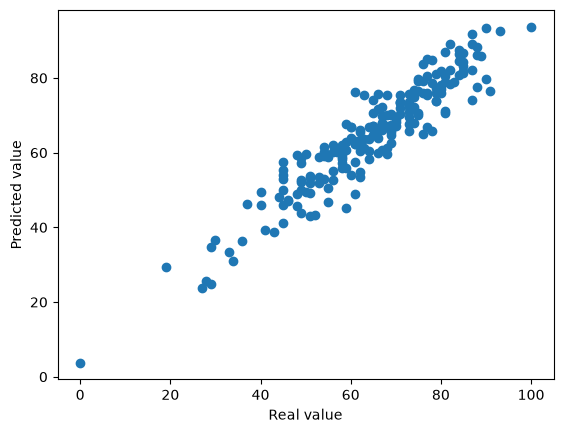

In [64]:
plt.scatter(y_test,y_predict_linear)
plt.xlabel("Real value")
plt.ylabel("Predicted value")

<Axes: xlabel='math_score'>

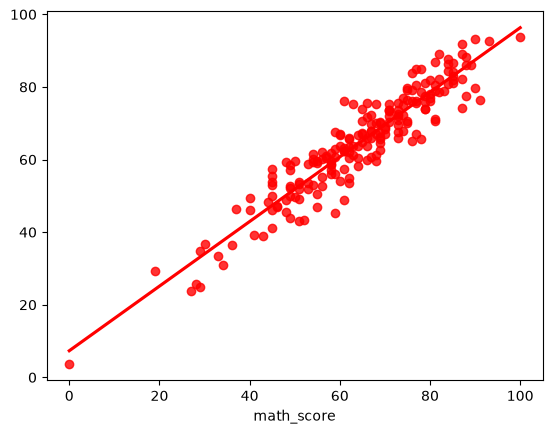

In [67]:
sns.regplot(x=y_test,y=y_predict_linear,ci=None,color="red")

Difference between actual value and pred value 

In [68]:
visualize = pd.DataFrame({'Actual value':y_test,
                        'pred value':y_predict_linear,
                        'difference between':y_test-y_predict_linear},
                         )

In [69]:
visualize

,Actual value,pred value,difference between
521,91,76.387970,14.612030
737,53,58.885970,-5.885970
740,80,76.990265,3.009735
660,74,76.851804,-2.851804
411,84,87.627378,-3.627378
...,...,...,...
408,52,43.409149,8.590851
332,62,62.152214,-0.152214
208,74,67.888395,6.111605
613,65,67.022287,-2.022287


np.int64(0)